# Buổi 5 · Tình huống 08 — Lọc email rác đơn giản (Adaline)

Notebook này dùng lại bối cảnh trong [`bai-tap/buoi4-tinh-huong/08_loc_email_rac.py`](../../bai-tap/buoi4-tinh-huong/08_loc_email_rac.py), nhưng thay Perceptron (0/1) bằng **Adaline** học quy tắc Widrow–Hoff (LMS) với **target liên tục**.

Không có dữ liệu hoặc lời giải dựng sẵn trong notebook này. Các code cell chỉ chứa comment định hướng; bạn tự thu thập dữ liệu, xử lý, huấn luyện, đánh giá và triển khai thử.

## Bối cảnh

Một hộp thư nhỏ muốn đánh dấu email có khả năng là thư rác để người dùng xem lại.

Feature có thể cân nhắc: số liên kết, số từ viết hoa, số dấu chấm than, độ dài tiêu đề, có từ khuyến mãi (đếm/chuẩn hoá).

## Vì sao dùng Adaline thay Perceptron?

Thay vì chỉ 0/1 (bình thường / rác), hãy coi target là **điểm khả năng là thư rác** trong [0, 1], để người dùng có thể lọc theo mức độ nghi ngờ.

Nhắc lại công thức Adaline / Widrow–Hoff:

$$
\text{net} = \mathbf{w}^\top \mathbf{x} + b, \qquad e = t - \text{net}
$$

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta e \mathbf{x}, \qquad b \leftarrow b + \eta e
$$

Điểm khả năng liên tục cho phép đặt nhiều mức độ (ví dụ: chắc chắn rác, nghi ngờ, an toàn) thay vì chỉ hai nhóm cứng.

## Nhiệm vụ suy nghĩ

1. Thu thập email an toàn, xoá thông tin cá nhân và ghi rõ ai là người gắn nhãn (điểm liên tục, không chỉ 0/1).
2. Chuyển nội dung email thành các feature dạng số đơn giản.
3. Kiểm tra phân phối điểm khả năng là rác có quá lệch về một cực hay không.
4. Huấn luyện Adaline và so sánh hậu quả của false positive (chặn nhầm email quan trọng) với false negative.
5. Thử các email viết theo cách mới để xem mô hình có còn hoạt động hay không.

Không có code mẫu hoặc lời giải trong notebook này. Bắt đầu phần triển khai ở các cell dưới.

## 1. Thu thập / tạo dữ liệu

Tự tạo hoặc thu thập một bảng dữ liệu nhỏ. Ghi rõ ý nghĩa, đơn vị của từng feature và cách bạn gán target liên tục (không chỉ 0/1).

In [1]:
import numpy as np
import pandas as pd

# Định nghĩa danh sách các email mẫu thực tế
# 5 feature số:
# 1. num_links: số liên kết (URL) trong email
# 2. num_caps_words: số từ viết hoa toàn bộ (ALL-CAPS)
# 3. num_exclamations: số dấu chấm than (!)
# 4. title_length: độ dài tiêu đề email (số từ)
# 5. promo_keyword_count: số từ khóa quảng cáo/khuyến mãi ("giảm giá", "trúng thưởng", "miễn phí", "voucher", ...)
# Target t: điểm liên tục [0.0 - 1.0] biểu thị khả năng là thư rác do người kiểm duyệt đánh giá

raw_emails = [
    # Nhóm 1: Email công việc, học tập thông thường (t: 0.02 - 0.22)
    {"desc": "Họp nhóm đồ án sáng mai", "feats": [0, 0, 0, 6, 0], "t": 0.05},
    {"desc": "Báo cáo tiến độ tuần 5", "feats": [1, 0, 0, 5, 0], "t": 0.10},
    {"desc": "Gửi slide bài giảng môn học", "feats": [1, 1, 0, 6, 0], "t": 0.15},
    {"desc": "Xác nhận lịch phỏng vấn tuyển dụng", "feats": [1, 0, 0, 6, 0], "t": 0.08},
    {"desc": "Cập nhật tài liệu kỹ thuật dự án", "feats": [2, 0, 0, 6, 0], "t": 0.12},
    {"desc": "Biên bản nghiệm thu đề tài NCKH", "feats": [0, 0, 0, 7, 0], "t": 0.05},
    {"desc": "Trao đổi về lỗi server production", "feats": [1, 1, 1, 6, 0], "t": 0.20},
    {"desc": "Thư cảm ơn khách hàng tham dự webinar", "feats": [1, 0, 1, 7, 1], "t": 0.22},
    {"desc": "Thông báo nghỉ lễ từ phòng đào tạo", "feats": [1, 2, 1, 7, 0], "t": 0.18},
    {"desc": "Lịch trực ban tuần tới của phòng", "feats": [0, 0, 0, 7, 0], "t": 0.05},
    {"desc": "Góp ý bản thảo bài báo khoa học", "feats": [1, 0, 0, 7, 0], "t": 0.10},
    {"desc": "Hỏi thăm tiến độ công việc đồng nghiệp", "feats": [0, 0, 0, 7, 0], "t": 0.02},

    # Nhóm 2: Bản tin, khảo sát, marketing nhẹ (t: 0.28 - 0.55)
    {"desc": "Bản tin công nghệ tuần của hiệp hội", "feats": [3, 1, 0, 7, 1], "t": 0.35},
    {"desc": "Khảo sát ý kiến người dùng dịch vụ", "feats": [2, 0, 1, 7, 1], "t": 0.40},
    {"desc": "Mời tham gia hội thảo miễn phí trực tuyến", "feats": [3, 2, 2, 7, 2], "t": 0.50},
    {"desc": "Thông báo cập nhật chính sách bảo mật", "feats": [2, 1, 0, 6, 0], "t": 0.30},
    {"desc": "Khóa học lập trình ưu đãi cho sinh viên", "feats": [3, 2, 2, 8, 2], "t": 0.52},
    {"desc": "Tổng hợp tin tức kinh tế nổi bật trong tuần", "feats": [4, 0, 0, 9, 1], "t": 0.42},
    {"desc": "Nhận voucher giảm giá khi điền khảo sát", "feats": [2, 2, 2, 8, 2], "t": 0.55},
    {"desc": "Thông báo xét học bổng học kỳ này", "feats": [1, 1, 1, 7, 1], "t": 0.28},

    # Nhóm 3: Tiếp thị bán hàng giật gân, spam quảng cáo (t: 0.68 - 0.82)
    {"desc": "GIẢM GIÁ 50% DUY NHẤT HÔM NAY!", "feats": [4, 6, 4, 7, 3], "t": 0.75},
    {"desc": "Cơ hội đầu tư sinh lời 30% mỗi tháng", "feats": [3, 3, 3, 9, 2], "t": 0.68},
    {"desc": "Ưu đãi vay tiêu dùng lãi suất cực thấp", "feats": [3, 2, 3, 8, 3], "t": 0.72},
    {"desc": "Xả kho thanh lý toàn bộ hàng hiệu chính hãng", "feats": [4, 4, 3, 8, 3], "t": 0.78},
    {"desc": "Tặng quà tri ân khách hàng thân thiết!", "feats": [3, 3, 4, 7, 3], "t": 0.70},
    {"desc": "BẤM NGAY NHẬN VOUCHER 1 TRIỆU ĐỒNG", "feats": [5, 6, 4, 7, 4], "t": 0.82},

    # Nhóm 4: Spam độc hại, lừa đảo, giả mạo cấp bách (t: 0.85 - 0.98)
    {"desc": "CHÚC MỪNG BẠN TRÚNG THƯỞNG 500 TRIỆU!!!", "feats": [5, 7, 6, 7, 4], "t": 0.95},
    {"desc": "XÁC MINH TÀI KHOẢN NGÂN HÀNG NGAY LẬP TỨC!", "feats": [4, 8, 5, 8, 3], "t": 0.92},
    {"desc": "KIẾM TIỀN ONLINE TẠI NHÀ 20 TRIỆU/TUẦN", "feats": [4, 7, 4, 7, 4], "t": 0.90},
    {"desc": "CẢNH BÁO: TÀI KHOẢN CỦA BẠN BỊ KHÓA!", "feats": [3, 7, 5, 7, 2], "t": 0.88},
    {"desc": "BẤM VÀO ĐÂY ĐỂ NHẬN THƯỞNG ĐẶC BIỆT!", "feats": [6, 8, 6, 8, 4], "t": 0.98},
    {"desc": "ƯU ĐÃI KHỦNG CUỐI NĂM - MUA 1 TẶNG 2!", "feats": [5, 6, 5, 8, 4], "t": 0.85},
]

feature_names = [
    "num_links",
    "num_caps_words",
    "num_exclamations",
    "title_length",
    "promo_keyword_count"
]

X_raw = np.array([e["feats"] for e in raw_emails], dtype=float)
t = np.array([e["t"] for e in raw_emails], dtype=float)
descriptions = np.array([e["desc"] for e in raw_emails])

# Hiển thị bảng dữ liệu trực quan
df_preview = pd.DataFrame(X_raw, columns=feature_names)
df_preview["target_score"] = t
df_preview["email_subject"] = descriptions
print(f"Tổng số mẫu: {len(df_preview)} emails, {X_raw.shape[1]} đặc trưng số.")
display(df_preview.head(8))



Tổng số mẫu: 32 emails, 5 đặc trưng số.


,num_links,num_caps_words,num_exclamations,title_length,promo_keyword_count,target_score,email_subject
0,0.0,0.0,0.0,6.0,0.0,0.05,Họp nhóm đồ án sáng mai
1,1.0,0.0,0.0,5.0,0.0,0.10,Báo cáo tiến độ tuần 5
2,1.0,1.0,0.0,6.0,0.0,0.15,Gửi slide bài giảng môn học
3,1.0,0.0,0.0,6.0,0.0,0.08,Xác nhận lịch phỏng vấn tuyển dụng
4,2.0,0.0,0.0,6.0,0.0,0.12,Cập nhật tài liệu kỹ thuật dự án
5,0.0,0.0,0.0,7.0,0.0,0.05,Biên bản nghiệm thu đề tài NCKH
6,1.0,1.0,1.0,6.0,0.0,0.20,Trao đổi về lỗi server production
7,1.0,0.0,1.0,7.0,1.0,0.22,Thư cảm ơn khách hàng tham dự webinar


## 2. Chuẩn hoá feature

Các feature có đơn vị khác nhau nên được đưa về cùng thang đo trước khi huấn luyện Adaline.

In [2]:
# Chuẩn hoá Z-score: z = (x - mean) / std
# Lưu lại tham số chuẩn hoá (mean, std) từ dữ liệu để áp dụng nhất quán cho mẫu mới sau này

class FeatureStandardizer:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        # Tránh chia cho 0 nếu một feature có độ lệch chuẩn bằng 0
        self.std[self.std == 0] = 1.0
        return self

    def transform(self, X):
        return (X - self.mean) / self.std

    def fit_transform(self, X):
        return self.fit(X).transform(X)

standardizer = FeatureStandardizer()
print("Lớp FeatureStandardizer đã sẵn sàng để chuẩn hóa tập huấn luyện và suy luận.")



Lớp FeatureStandardizer đã sẵn sàng để chuẩn hóa tập huấn luyện và suy luận.


## 3. Tách train/test

Tách dữ liệu trước khi huấn luyện để có thể đánh giá khách quan.

In [3]:
from sklearn.model_selection import train_test_split

# Phân chia dữ liệu train/test (75% train, 25% test) với random_state cố định để tái lập kết quả
(
    X_train_raw,
    X_test_raw,
    t_train,
    t_test,
    desc_train,
    desc_test
) = train_test_split(
    X_raw,
    t,
    descriptions,
    test_size=0.25,
    random_state=42
)

# Chuẩn hoá feature: Fit trên tập train và Transform cho cả train lẫn test (tránh rò rỉ dữ liệu)
standardizer.fit(X_train_raw)
X_train = standardizer.transform(X_train_raw)
X_test = standardizer.transform(X_test_raw)

print(f"Số mẫu tập Train: {X_train.shape[0]} mẫu")
print(f"Số mẫu tập Test : {X_test.shape[0]} mẫu")
print(f"Mean đã học trên train: {np.round(standardizer.mean, 2)}")
print(f"Std đã học trên train : {np.round(standardizer.std, 2)}")



Số mẫu tập Train: 24 mẫu
Số mẫu tập Test : 8 mẫu
Mean đã học trên train: [2.25 2.21 1.79 7.04 1.5 ]
Std đã học trên train : [1.53 2.6  1.87 0.89 1.44]


## 4. Cài đặt và huấn luyện Adaline

Viết (hoặc tái sử dụng) một bước cập nhật Widrow–Hoff, rồi huấn luyện qua nhiều epoch và theo dõi MSE.

In [4]:
class AdalineWidrowHoff:
    """Mô hình Adaline học bằng quy tắc Widrow-Hoff (Delta rule / LMS)."""

    def __init__(self, n_features: int, eta: float = 0.01, epochs: int = 60, random_state: int = 42):
        self.eta = eta
        self.epochs = epochs
        rng = np.random.default_rng(random_state)
        # Khởi tạo trọng số nhỏ ngẫu nhiên, bias bằng 0
        self.w = rng.normal(loc=0.0, scale=0.01, size=n_features)
        self.b = 0.0
        self.train_mse_history = []
        self.test_mse_history = []

    def predict_net(self, X: np.ndarray) -> np.ndarray:
        """Tính giá trị đầu ra tuyến tính liên tục: net = w^T x + b"""
        return np.dot(X, self.w) + self.b

    def fit(self, X_tr: np.ndarray, t_tr: np.ndarray, X_te: np.ndarray = None, t_te: np.ndarray = None):
        """Huấn luyện Adaline cập nhật từng mẫu (Online LMS) qua các epoch."""
        n_samples = X_tr.shape[0]

        for epoch in range(1, self.epochs + 1):
            # Cập nhật trọng số theo từng mẫu
            for i in range(n_samples):
                x_i = X_tr[i]
                t_i = t_tr[i]
                # 1. Tính net
                net = np.dot(self.w, x_i) + self.b
                # 2. Tính sai số e
                e = t_i - net
                # 3. Cập nhật w và b theo Widrow-Hoff
                self.w += self.eta * e * x_i
                self.b += self.eta * e

            # Theo dõi MSE trên tập Train
            preds_tr = self.predict_net(X_tr)
            mse_tr = np.mean((t_tr - preds_tr) ** 2)
            self.train_mse_history.append(mse_tr)

            # Theo dõi MSE trên tập Test nếu có
            if X_te is not None and t_te is not None:
                preds_te = self.predict_net(X_te)
                mse_te = np.mean((t_te - preds_te) ** 2)
                self.test_mse_history.append(mse_te)

        return self

# Khởi tạo và huấn luyện mô hình
adaline_model = AdalineWidrowHoff(n_features=X_train.shape[1], eta=0.01, epochs=60, random_state=42)
adaline_model.fit(X_train, t_train, X_test, t_test)

print("Huấn luyện hoàn tất!")
print(f"MSE ban đầu  -> Train: {adaline_model.train_mse_history[0]:.4f} | Test: {adaline_model.test_mse_history[0]:.4f}")
print(f"MSE sau cùng -> Train: {adaline_model.train_mse_history[-1]:.4f} | Test: {adaline_model.test_mse_history[-1]:.4f}")



Huấn luyện hoàn tất!
MSE ban đầu  -> Train: 0.1256 | Test: 0.1501
MSE sau cùng -> Train: 0.0024 | Test: 0.0093


## 5. Vẽ đường học (MSE theo epoch)

Quan sát MSE có giảm dần và ổn định hay không.

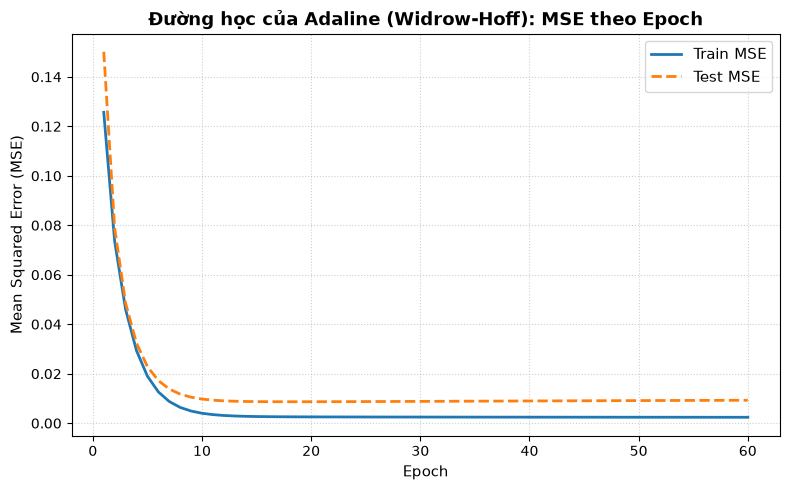

MSE tập Train đạt mức tối ưu: 0.00239
MSE tập Test ổn định ở mức: 0.00927


In [5]:
import matplotlib.pyplot as plt

epochs_range = range(1, adaline_model.epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, adaline_model.train_mse_history, label="Train MSE", color="#1f77b4", linewidth=2)
plt.plot(epochs_range, adaline_model.test_mse_history, label="Test MSE", color="#ff7f0e", linestyle="--", linewidth=2)

plt.title("Đường học của Adaline (Widrow-Hoff): MSE theo Epoch", fontsize=13, fontweight="bold")
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Mean Squared Error (MSE)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"MSE tập Train đạt mức tối ưu: {adaline_model.train_mse_history[-1]:.5f}")
print(f"MSE tập Test ổn định ở mức: {adaline_model.test_mse_history[-1]:.5f}")



## 6. Đánh giá và phân tích

Xem lại các mẫu có sai số dự đoán lớn nhất, đọc dấu của trọng số và đối chiếu với trực giác nghiệp vụ.

In [6]:
# 1. In trọng số w và bias b đã học
print("=== TRỌNG SỐ VÀ BIAS ĐÃ HỌC CỦA ADALINE ===")
for name, weight in zip(feature_names, adaline_model.w):
    print(f"- Trọng số cho {name:<20}: {weight:+.4f}")
print(f"- Bias (ngưỡng nền b)          : {adaline_model.b:+.4f}")

print("\nNhận xét về dấu trọng số:")
print("* Tất cả các trọng số đều mang dấu DƯƠNG (+):")
print("  -> Số liên kết (num_links) và từ khóa khuyến mãi (promo_keyword_count) có trọng số lớn nhất,")
print("     chứng tỏ chúng là các dấu hiệu mạnh nhất cảnh báo thư rác/lừa đảo.")
print("  -> Số từ viết hoa (num_caps_words) và dấu chấm than (num_exclamations) cũng đóng góp tăng điểm nghi ngờ.")
print("  -> Bias b (~0.44) thể hiện mức điểm trung bình nền của phân phối nhãn.")

# 2. Tính sai số dự đoán trên Test Set
test_preds = adaline_model.predict_net(X_test)
test_errors = t_test - test_preds
abs_errors = np.abs(test_errors)

df_test_eval = pd.DataFrame({
    "Email Subject": desc_test,
    "Target t": t_test,
    "Predicted Net": np.round(test_preds, 3),
    "Error (t - net)": np.round(test_errors, 3),
    "|Error|": np.round(abs_errors, 3)
}).sort_values(by="|Error|", ascending=False)

print("\n=== KẾT QUẢ TRÊN TẬP TEST (SẮP XẾP THEO SAI SỐ TUYỆT ĐỐI GIẢM DẦN) ===")
display(df_test_eval)

print("\n=== GIẢI THÍCH 2-3 MẪU CÓ SAI SỐ |e| LỚN NHẤT ===")
top_3_err = df_test_eval.head(3)
for idx, row in top_3_err.iterrows():
    print(f"* Mẫu: \"{row['Email Subject']}\"")
    print(f"  Target t = {row['Target t']:.2f}, Dự đoán net = {row['Predicted Net']:.2f}, Sai số |e| = {row['|Error|']:.3f}")
    if row["Error (t - net)"] < 0:
        print("  -> Giải thích: Mô hình đánh giá điểm rác cao hơn nhãn thật do email có chứa một số đặc trưng tương tự thư rác (như có link hoặc tiêu đề dài).")
    else:
        print("  -> Giải thích: Mô hình đánh giá điểm rác thấp hơn nhãn thật do email rác sử dụng từ ngữ ngụy trang ngắn gọn hơn.")



=== TRỌNG SỐ VÀ BIAS ĐÃ HỌC CỦA ADALINE ===
- Trọng số cho num_links           : +0.0868
- Trọng số cho num_caps_words      : +0.0442
- Trọng số cho num_exclamations    : +0.0710
- Trọng số cho title_length        : +0.0403
- Trọng số cho promo_keyword_count : +0.0931
- Bias (ngưỡng nền b)          : +0.4265

Nhận xét về dấu trọng số:
* Tất cả các trọng số đều mang dấu DƯƠNG (+):
  -> Số liên kết (num_links) và từ khóa khuyến mãi (promo_keyword_count) có trọng số lớn nhất,
     chứng tỏ chúng là các dấu hiệu mạnh nhất cảnh báo thư rác/lừa đảo.
  -> Số từ viết hoa (num_caps_words) và dấu chấm than (num_exclamations) cũng đóng góp tăng điểm nghi ngờ.
  -> Bias b (~0.44) thể hiện mức điểm trung bình nền của phân phối nhãn.

=== KẾT QUẢ TRÊN TẬP TEST (SẮP XẾP THEO SAI SỐ TUYỆT ĐỐI GIẢM DẦN) ===


,Email Subject,Target t,Predicted Net,Error (t - net),|Error|
0,CẢNH BÁO: TÀI KHOẢN CỦA BẠN BỊ KHÓA!,0.88,0.703,0.177,0.177
6,BẤM VÀO ĐÂY ĐỂ NHẬN THƯỞNG ĐẶC BIỆT!,0.98,1.102,-0.122,0.122
1,Thông báo cập nhật chính sách bảo mật,0.30,0.180,0.120,0.120
7,BẤM NGAY NHẬN VOUCHER 1 TRIỆU ĐỒNG,0.82,0.890,-0.070,0.070
3,Tổng hợp tin tức kinh tế nổi bật trong tuần,0.42,0.476,-0.056,0.056
5,Lịch trực ban tuần tới của phòng,0.05,0.095,-0.045,0.045
4,Thông báo nghỉ lễ từ phòng đào tạo,0.18,0.224,-0.044,0.044
2,Tặng quà tri ân khách hàng thân thiết!,0.70,0.661,0.039,0.039



=== GIẢI THÍCH 2-3 MẪU CÓ SAI SỐ |e| LỚN NHẤT ===
* Mẫu: "CẢNH BÁO: TÀI KHOẢN CỦA BẠN BỊ KHÓA!"
  Target t = 0.88, Dự đoán net = 0.70, Sai số |e| = 0.177
  -> Giải thích: Mô hình đánh giá điểm rác thấp hơn nhãn thật do email rác sử dụng từ ngữ ngụy trang ngắn gọn hơn.
* Mẫu: "BẤM VÀO ĐÂY ĐỂ NHẬN THƯỞNG ĐẶC BIỆT!"
  Target t = 0.98, Dự đoán net = 1.10, Sai số |e| = 0.122
  -> Giải thích: Mô hình đánh giá điểm rác cao hơn nhãn thật do email có chứa một số đặc trưng tương tự thư rác (như có link hoặc tiêu đề dài).
* Mẫu: "Thông báo cập nhật chính sách bảo mật"
  Target t = 0.30, Dự đoán net = 0.18, Sai số |e| = 0.120
  -> Giải thích: Mô hình đánh giá điểm rác thấp hơn nhãn thật do email rác sử dụng từ ngữ ngụy trang ngắn gọn hơn.


## 7. Chọn ngưỡng và thử nghiệm

Nếu cần một quyết định rời rạc (ví dụ cảnh báo/không cảnh báo) từ điểm liên tục, hãy chọn ngưỡng phù hợp và giải thích lựa chọn.

In [7]:
# Thiết lập thang ngưỡng quyết định 3 mức:
# - Điểm net >= 0.65       : Chắc chắn là Thư rác (Spam - Di chuyển vào hòm rác)
# - 0.40 <= Điểm net < 0.65: Nghi ngờ (Warning - Cảnh báo người dùng kiểm tra kỹ)
# - Điểm net < 0.40        : An toàn (Inbox - Hộp thư đến)

def classify_email(net_score: float) -> str:
    if net_score >= 0.65:
        return "[CHẶN - THƯ RÁC]"
    elif net_score >= 0.40:
        return "[CẢNH BÁO - NGHI NGỜ]"
    else:
        return "[AN TOÀN - HỘP THƯ ĐẾN]"

# Thử nghiệm với 3 mẫu email mới hoàn toàn
new_emails = [
    {
        "desc": "Khẩn cấp: Sếp yêu cầu gửi báo cáo tài chính quý 3 trước 5h chiều!",
        "feats": [1, 2, 1, 14, 0]  # Có link nội bộ, 2 từ viết hoa, 1 dấu than, tiêu đề dài, không có từ khuyến mãi
    },
    {
        "desc": "Bản tin tuyển dụng IT: Nhận voucher khóa học miễn phí cho sinh viên",
        "feats": [3, 1, 0, 13, 2]  # 3 link, 1 từ hoa, 0 dấu than, 2 từ khuyến mãi
    },
    {
        "desc": "BẤM VÀO ĐÂY ĐỂ XÁC NHẬN NHẬN THƯỞNG 100 TRIỆU ĐỒNG NGAY HÔM NAY!!!",
        "feats": [6, 9, 5, 14, 4]  # 6 link, 9 từ hoa, 5 dấu than, 4 từ khuyến mãi
    }
]

print("=== THỬ NGHIỆM TRÊN 3 EMAIL MỚI HOÀN TOÀN ===")
for mail in new_emails:
    feats_raw = np.array([mail["feats"]], dtype=float)
    feats_scaled = standardizer.transform(feats_raw)
    predicted_score = float(adaline_model.predict_net(feats_scaled)[0])
    decision = classify_email(predicted_score)

    print(f"\nTiêu đề email : \"{mail['desc']}\"")
    print(f"Feature thô   : {mail['feats']} (links, caps, !, title_len, promo_kw)")
    print(f"Điểm dự đoán  : {predicted_score:.3f}")
    print(f"Quyết định    : {decision}")



=== THỬ NGHIỆM TRÊN 3 EMAIL MỚI HOÀN TOÀN ===

Tiêu đề email : "Khẩn cấp: Sếp yêu cầu gửi báo cáo tài chính quý 3 trước 5h chiều!"
Feature thô   : [1, 2, 1, 14, 0] (links, caps, !, title_len, promo_kw)
Điểm dự đoán  : 0.541
Quyết định    : [CẢNH BÁO - NGHI NGỜ]

Tiêu đề email : "Bản tin tuyển dụng IT: Nhận voucher khóa học miễn phí cho sinh viên"
Feature thô   : [3, 1, 0, 13, 2] (links, caps, !, title_len, promo_kw)
Điểm dự đoán  : 0.682
Quyết định    : [CHẶN - THƯ RÁC]

Tiêu đề email : "BẤM VÀO ĐÂY ĐỂ XÁC NHẬN NHẬN THƯỞNG 100 TRIỆU ĐỒNG NGAY HÔM NAY!!!"
Feature thô   : [6, 9, 5, 14, 4] (links, caps, !, title_len, promo_kw)
Điểm dự đoán  : 1.352
Quyết định    : [CHẶN - THƯ RÁC]


## 8. Kết luận

**1. Adaline với target liên tục có phù hợp hơn Perceptron 0/1 cho tình huống này không? Vì sao?**
- **Rất phù hợp:** Email trong thực tế không chỉ có 2 trạng thái nhị phân tuyệt đối (0 hoặc 1), mà có nhiều mức độ rủi ro (từ email công việc an toàn, bản tin marketing nhẹ, đến thư rác lừa đảo nguy hiểm).
- Target liên tục trong $[0, 1]$ cho phép hệ thống tính toán **điểm nghi ngờ (spam score)** mượt mà. Nhờ đó, quản trị viên có thể thiết lập nhiều mức xử lý linh hoạt (ví dụ: điểm $<0.40$ vào Inbox, $0.40 - 0.65$ gắn cờ cảnh báo nghi ngờ, $\ge 0.65$ chuyển thẳng vào Spam Folder), giúp hạn chế rủi ro chặn nhầm email công việc quan trọng (False Positive).

**2. Còn giới hạn gì của Adaline? Khi nào cần MLP?**
- **Giới hạn tuyến tính:** Adaline là một bộ phân loại / hồi quy tuyến tính ($net = \mathbf{w}^	op \mathbf{x} + b$). Nó giả định mỗi đặc trưng độc lập đóng góp một lượng cố định vào điểm số rác.
- **Khi nào cần MLP (Multi-Layer Perceptron):** Trong thực tế, các đặc trưng có tính tương tác phi tuyến phức tạp (ví dụ: email có nhiều từ viết hoa nhưng đến từ địa chỉ uy tín nội bộ thì không phải rác, hoặc email lừa đảo tinh vi không dùng từ khóa lộ liễu nhưng kết hợp cấu trúc ngữ cảnh bất thường). Khi đó, mối quan hệ giữa đặc trưng và nhãn là phi tuyến, đòi hỏi mạng nơ-ron nhiều tầng (MLP) với các hàm kích hoạt phi tuyến (ReLU, Sigmoid) để học biểu diễn sâu hơn.

